# 🔭 Classifying the Changing Sky with FLARE

### A hands-on lesson in machine learning for astronomy

Every clear night, robotic telescopes like the **Zwicky Transient Facility (ZTF)**
photograph the sky over and over, looking for things that *change*: stars that
explode, black holes that flare up, stars being torn apart. Astronomers call these
**transients** — and there are far too many each night for humans to check by hand.

In this notebook you will build up, step by step, the machine-learning system called
**FLARE** (*Feature-based Light-curve Aggregated Ranking Ensemble*) that classifies
five kinds of objects from their **light curves** (brightness over time):

| Class | What it is | How its light behaves |
|---|---|---|
| **SNI** | Type I supernova — a white dwarf explodes | fast rise, smooth decline, turns red |
| **SNII** | Type II supernova — a massive star collapses | slower, often a "plateau" |
| **CV** | Cataclysmic variable — a vampire star feeding off a companion | repeated outbursts |
| **AGN** | Active galactic nucleus — a feeding supermassive black hole | flickers randomly for years |
| **TDE** | Tidal disruption event — a star **shredded** by a black hole | smooth decline, stays **blue** |

**The plan:**
1. Look at real light curves 👀
2. Turn curves into *numbers that mean something physically* (features) 🧮
3. Let decision trees learn from the features 🌳
4. Ask the model *how sure* it is — honestly 🎲
5. Ask the model *why* — and check it learned real physics 🔬

> **Requirements:** the `flare` package (`pip install -e ..` from this folder's parent)
> plus `matplotlib`. You also need the ZTF `photo_events` dataset — set the
> environment variable `FLARE_DATA` to its path (or edit `DATA_DIR` below).

In [1]:
# --- Setup ---------------------------------------------------------------
import os, sys, glob, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")            # find the flare package if not pip-installed
from flare import FlareClassifier, BROAD_CLASSES
from flare import data as D
from flare.features import extract_object_features

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

# one colour per class, fixed everywhere (colour-blind friendly)
CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Setup OK — classes:", BROAD_CLASSES)

Setup OK — classes: ['SNI', 'SNII', 'CV', 'AGN', 'TDE']


## 1. Meet the data: real light curves 👀

Each object is stored as a table of **detections**: at what time we saw it, in which
filter (**g** = green light, **r** = red light), and how bright it was.
Telescopes can't observe every night (weather! moon! daytime!), so the sampling is
**irregular** — that's one of the things that makes this problem hard.

Let's load the catalogue and plot one real example of each class.

In [2]:
# Load the test-set catalogue and pick one bright example per class
manifest = D.load_manifest("test")
from flare.taxonomy import ID2BROAD_ID
manifest["broad"] = manifest["label"].map(lambda x: BROAD_CLASSES[ID2BROAD_ID[int(x)]])
print(manifest["broad"].value_counts().to_string())
print(f"\nTotal objects in the test catalogue: {len(manifest)}")

broad
AGN     1336
SNI      993
SNII     253
CV       144
TDE       11

Total objects in the test catalogue: 2737


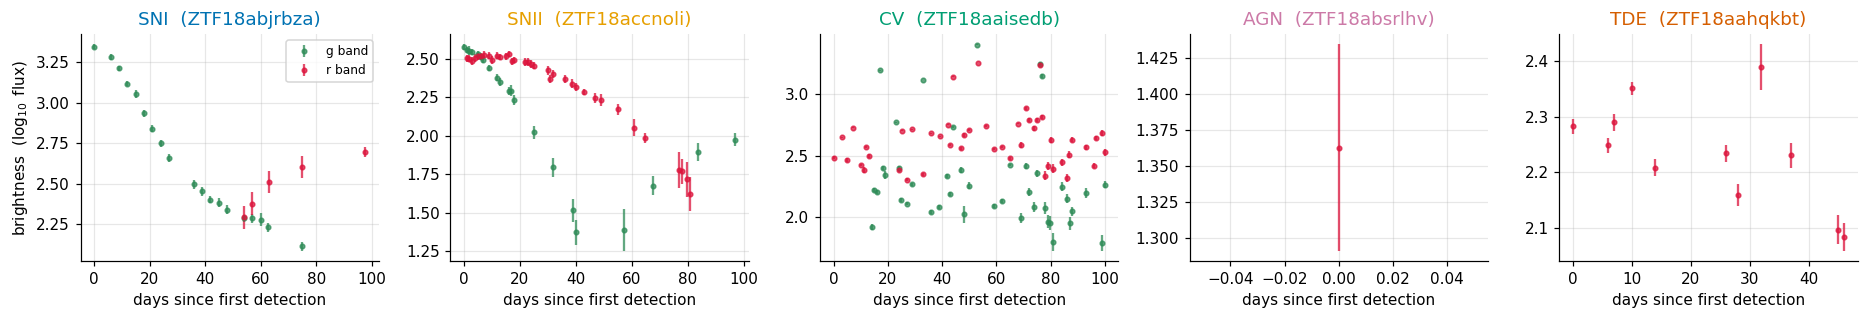

In [3]:
# Plot one example light curve per class
examples = {"SNI": "ZTF18abukavn", "SNII": None, "CV": None, "AGN": None, "TDE": None}
fig, axes = plt.subplots(1, 5, figsize=(17, 3.0))
for ax, cls in zip(axes, BROAD_CLASSES):
    # pick the object of this class with the most detections (prettiest curve)
    sub = manifest[manifest.broad == cls].nlargest(1, "n_events")
    row = sub.iloc[0]
    arr = D.load_events(row.filepath)          # (n_events, 15), first 100 days
    bands = D.reconstruct_bands(arr)           # per-band light curves
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            lc = bands[name]
            ax.errorbar(lc.t, lc.logflux, yerr=lc.logflux_err, fmt="o", ms=3,
                        color=colr, alpha=0.75, label=f"{name} band")
    ax.set_title(f"{cls}  ({row.obj_id})", color=CLASS_COLOR[cls])
    ax.set_xlabel("days since first detection")
axes[0].set_ylabel(r"brightness  ($\log_{10}$ flux)")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Look closely** — you can already *see* the physics:

* The **supernovae** rise fast and fade away (they are explosions — one-shot events).
* The **CV** jumps up and down (repeated outbursts).
* The **AGN** wanders randomly — it never "ends", it just flickers.
* The **TDE** declines smoothly, and its green (g) points sit *above* the red (r)
  points — it stays **blue and hot** as the black hole eats the star.

Our whole job is to teach a computer to notice the same things you just noticed.

### ✏️ Exercise 1
Change the code above to plot a *different* object of each class
(hint: replace `.nlargest(1, "n_events")` with `.sample(1)` and re-run).
Do the patterns hold?

## 2. From pictures to numbers: feature engineering 🧮

A computer can't "look" at a plot. We must convert each light curve into a fixed
list of **numbers that capture the physics** — these are called **features**.
FLARE computes **160** of them per object. A few examples:

| Feature | What it measures | Who it catches |
|---|---|---|
| `g_r_mean` | average colour (green − red brightness) | TDEs are **blue** → very negative |
| `g_r_std` | does the colour *change*? | supernovae turn red; TDEs don't |
| `g_eta_e` | is the curve smooth or jumpy? | AGN flicker; TDEs are smooth |
| `g_bazin_fall_time` | how many days to fade | explosions fade; AGN don't |
| `g_bazin_reduced_chi2` | does an "explosion-shaped" fit work at all? | separates transients from AGN/CV |

The `bazin` features come from fitting each curve with a physical rise-then-fall
model of an explosion (Bazin et al. 2009).

In [4]:
# Extract the 160 features for ONE object and peek at a few
row = manifest[manifest.broad == "TDE"].nlargest(1, "n_events").iloc[0]
feats = extract_object_features(row.filepath)
print(f"{row.obj_id} (a real TDE) → {len(feats)} features. A physicist's sample:\n")
for k in ["g_r_mean", "g_r_std", "g_eta_e", "g_bazin_fall_time", "g_bazin_reduced_chi2"]:
    print(f"  {k:24s} = {feats[k]: .3f}")

ZTF18aahqkbt (a real TDE) → 160 features. A physicist's sample:

  g_r_mean                 =  nan
  g_r_std                  =  nan
  g_eta_e                  =  nan
  g_bazin_fall_time        =  nan
  g_bazin_reduced_chi2     =  nan


E20260718 22:30:09.008812 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:30:10.031981 2128604 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 22:30:10.032027 2128604 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260718 22:30:10.032119 2128604 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 22:30:10.032174 2128604 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.


E20260718 22:30:12.617228 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:30:19.408083 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:30:21.546674 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


...

E20260718 22:31:21.480136 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:31:23.549278 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:31:24.499794 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:31:28.334291 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:31:40.128511 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


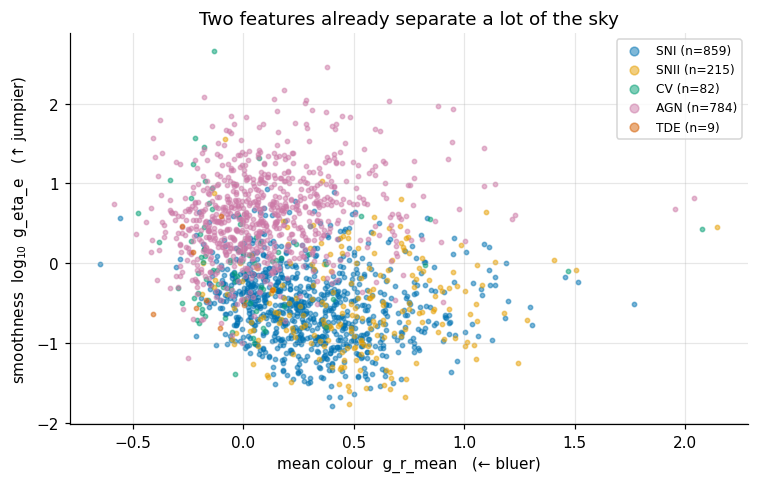

In [5]:
# Do these features actually separate the classes? Check the colour feature
# for every object in the test set (this takes ~10 seconds).
rows = []
for r in manifest.itertuples():
    f = extract_object_features(r.filepath)
    rows.append({"broad": r.broad, "g_r_mean": f["g_r_mean"], "g_eta_e": f["g_eta_e"]})
ft = pd.DataFrame(rows).dropna()

fig, ax = plt.subplots(figsize=(7, 4.5))
for cls in BROAD_CLASSES:
    sub = ft[ft.broad == cls]
    ax.scatter(sub.g_r_mean, np.log10(sub.g_eta_e.clip(1e-4)), s=8, alpha=0.5,
               color=CLASS_COLOR[cls], label=f"{cls} (n={len(sub)})")
ax.set_xlabel("mean colour  g_r_mean   (← bluer)")
ax.set_ylabel(r"smoothness  $\log_{10}$ g_eta_e   (↑ jumpier)")
ax.set_title("Two features already separate a lot of the sky")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

Two numbers — colour and smoothness — and the classes already form clouds!
The TDEs (orange) sit at *blue + smooth*; the AGN (pink) at *jumpy*.
But the clouds overlap, so we need something smarter than drawing lines by hand.

### ✏️ Exercise 2
Swap `g_eta_e` for `g_bazin_fall_time` in the plot above.
Which pair of classes does *that* feature separate best?

## 3. Let the trees decide 🌳

A **decision tree** asks yes/no questions about the features
(*"is `g_r_mean` < −0.2?"*) and routes each object down to a leaf with a class.
One tree is weak. **Gradient boosting** (we use **LightGBM**) builds *hundreds* of
small trees, each one correcting the mistakes of those before it — like a class of
students where every next student fixes the previous one's errors.

Why trees and not a deep neural network? For *tabular* data like our features,
boosted trees are famously hard to beat, they train in **minutes on a laptop CPU**,
they handle missing values natively (no i-band? no problem), and — crucially for
science — **you can ask them why**.

Let's train a *tiny* 2-feature model just to see the idea, then load the real one.

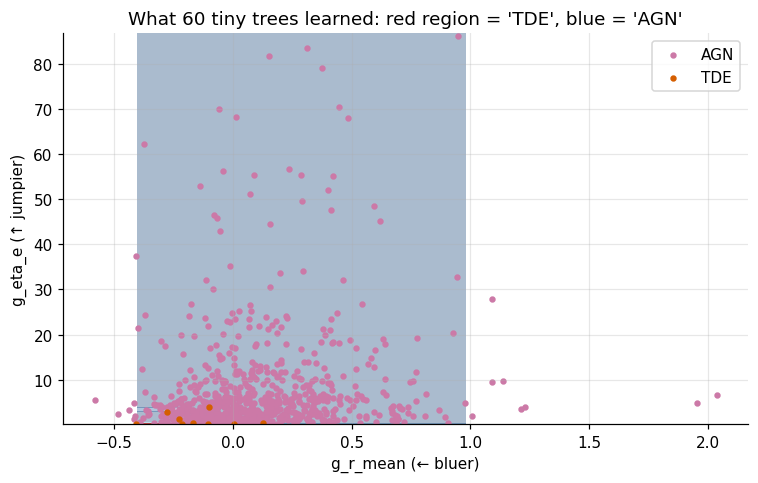

In [6]:
# A tiny 2-feature LightGBM, TDE vs AGN, just to visualise the decision boundary
import lightgbm as lgb
sub = ft[ft.broad.isin(["TDE", "AGN"])].copy()
X2 = sub[["g_r_mean", "g_eta_e"]].values
y2 = (sub.broad == "TDE").astype(int).values
mini = lgb.LGBMClassifier(n_estimators=60, num_leaves=7, class_weight="balanced",
                          verbosity=-1).fit(X2, y2)

# paint the plane with the model's decision
gx = np.linspace(*np.percentile(X2[:, 0], [1, 99]), 200)
gy = np.linspace(*np.percentile(X2[:, 1], [1, 99]), 200)
GX, GY = np.meshgrid(gx, gy)
Z = mini.predict_proba(np.c_[GX.ravel(), GY.ravel()])[:, 1].reshape(GX.shape)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.contourf(GX, GY, Z, levels=20, cmap="RdBu_r", alpha=0.35)
for cls in ["AGN", "TDE"]:
    s = sub[sub.broad == cls]
    ax.scatter(s.g_r_mean, s.g_eta_e, s=10, color=CLASS_COLOR[cls], label=cls)
ax.set_xlabel("g_r_mean (← bluer)"); ax.set_ylabel("g_eta_e (↑ jumpier)")
ax.set_ylim(gy[0], gy[-1])
ax.set_title("What 60 tiny trees learned: red region = 'TDE', blue = 'AGN'")
ax.legend()
plt.tight_layout(); plt.show()

The trees carved the plane into regions — note the boundary is *not* a straight
line; it bends around the data. The real FLARE does exactly this, but with
**160 features and 1140 trees**.

## 4. The real FLARE model 🚀

The trained model ships with the package — one file, ~5 MB. Let's load it and
classify some objects it has **never seen**.

In [7]:
clf = FlareClassifier.from_pretrained()
print(f"Loaded: {clf.booster.num_trees()} trees, {len(clf.feature_names)} features")

# classify five random test objects — one per class
picks = [manifest[manifest.broad == c].nlargest(1, "n_events").iloc[0] for c in BROAD_CLASSES]
files = [p.filepath for p in picks]
proba = clf.predict_proba_from_files(files)

df = pd.DataFrame(proba, columns=BROAD_CLASSES).round(3)
df.insert(0, "truth", [p.broad for p in picks])
df.insert(0, "object", [p.obj_id for p in picks])
df

Loaded: 1140 trees, 160 features


,object,truth,SNI,SNII,CV,AGN,TDE
0,ZTF18abjrbza,SNI,0.530,0.423,0.004,0.042,0.002
1,ZTF18accnoli,SNII,0.316,0.681,0.002,0.001,0.001
2,ZTF18aaisedb,CV,0.006,0.007,0.983,0.005,0.000
3,ZTF18absrlhv,AGN,0.012,0.006,0.053,0.929,0.000
4,ZTF18aahqkbt,TDE,0.044,0.312,0.045,0.596,0.002


Each row is a probability distribution over the five classes.
Now the honest question every scientist must ask:

## 5. Can we *trust* those probabilities? 🎲

If a model says "90%" for a thousand objects, then roughly **900 of them should
actually be that class**. When that holds, the model is **well-calibrated**.
Many powerful models are *overconfident* — they shout "99%!" and are wrong far more
than 1% of the time. FLARE's probabilities are honest almost out of the box
(its calibration error is about **0.01**, i.e. its "90%" really means ≈90%).

Let's verify this ourselves on the full test set — a **reliability diagram**: bin
the predictions by confidence, and check the actual accuracy in each bin.

In [8]:
# Evaluate on the full quality-filtered test set (~1 minute: 160 features x ~2000 objects)
kept, _ = D.filter_manifest_quality(manifest)
y_true = np.array([ID2BROAD_ID[int(l)] for l in kept.label])
X = clf.features_from_files(kept.filepath.tolist())
P = clf.predict_proba(X)
pred = P.argmax(1)
conf = P.max(1)
acc = (pred == y_true).mean()
print(f"N = {len(y_true)} unseen objects — overall accuracy: {acc:.3f}")

E20260718 22:33:45.705173 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 22:33:45.785200 2128604 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 22:33:45.785246 2128604 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260718 22:33:45.785341 2128604 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 22:33:45.785351 2128604 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.


E20260718 22:33:45.975618 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:46.416682 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 22:33:46.584762 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:47.375735 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 22:33:47.475631 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:48.471288 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


...

E20260718 22:33:51.036578 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 22:33:51.188949 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:51.412050 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 22:33:51.476840 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:51.721639 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 22:33:52.765908 2128604 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


N = 1979 unseen objects — overall accuracy: 0.957


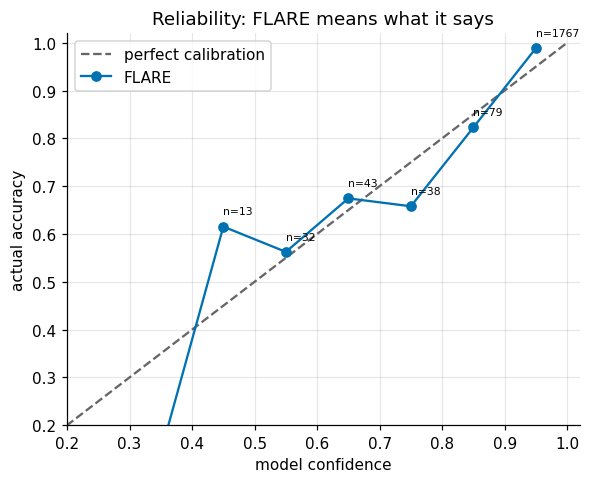

In [9]:
# Reliability diagram: does "x% confident" mean "x% correct"?
bins = np.linspace(0.2, 1.0, 9)
mids, accs, sizes = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (conf > lo) & (conf <= hi)
    if m.sum() < 5: continue
    mids.append((lo+hi)/2); accs.append((pred[m] == y_true[m]).mean()); sizes.append(m.sum())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="0.4", label="perfect calibration")
ax.plot(mids, accs, "-o", color="#0072B2", label="FLARE")
for x0, a, n in zip(mids, accs, sizes):
    ax.annotate(f"n={n}", (x0, a), textcoords="offset points", xytext=(0, 8), fontsize=7)
ax.set_xlabel("model confidence"); ax.set_ylabel("actual accuracy")
ax.set_title("Reliability: FLARE means what it says")
ax.legend(); ax.set_xlim(0.2, 1.02); ax.set_ylim(0.2, 1.02)
plt.tight_layout(); plt.show()

The blue curve hugs the diagonal → when FLARE says 80%, it *is* right about 80%
of the time. That is what lets a telescope scheduler act on these numbers.

## 6. Knowing what you don't know: conformal prediction 🎯

Sometimes one probability isn't enough — for a rare, precious TDE candidate you
want a **guarantee**. **Conformal prediction** turns probabilities into a
**prediction set**: a shortlist of classes that contains the true one at least
90% of the time — *guaranteed by mathematics*, separately **for every class**
(so the guarantee also holds for the rare TDEs, not just the plentiful supernovae).

* Easy object → set of one: `['AGN']` — done.
* Genuinely ambiguous object → set of two: `['TDE', 'AGN']` — "worth a spectrum!"''

In [10]:
sets = clf.prediction_sets(X)
set_sizes = np.array([len(s) for s in sets])
covered = np.array([BROAD_CLASSES[t] in s for t, s in zip(y_true, sets)])
print(f"Average shortlist size : {set_sizes.mean():.2f} classes")
print(f"Truth inside shortlist : {covered.mean():.1%}  (target ≥ 90%)\n")

# show a few interesting (ambiguous) cases
amb = np.where(set_sizes >= 2)[0][:5]
for i in amb:
    print(f"  {kept.iloc[i].obj_id}: truth={BROAD_CLASSES[y_true[i]]:4s}  shortlist={sets[i]}")

Average shortlist size : 0.96 classes
Truth inside shortlist : 90.7%  (target ≥ 90%)

  ZTF20abjawew: truth=AGN   shortlist=['SNII', 'TDE']
  ZTF19abzpvaj: truth=SNII  shortlist=['SNII', 'TDE']
  ZTF22aahgubb: truth=SNII  shortlist=['SNII', 'TDE']
  ZTF23abcufxh: truth=SNI   shortlist=['SNI', 'TDE']
  ZTF20acghodf: truth=SNII  shortlist=['SNII', 'TDE']


### ✏️ Exercise 3
Find the objects whose shortlist contains `TDE` but whose top guess is *not* TDE.
These are exactly the objects a TDE-hunter would send to a big telescope.
How many are there?

## 7. Why did it say TDE? Opening the box 🔬

Because FLARE is made of decision trees over *physical* features, we can rank which
features its decisions rely on. If the model has learned real astrophysics, the
top features should match what you saw in Section 1 with your own eyes.

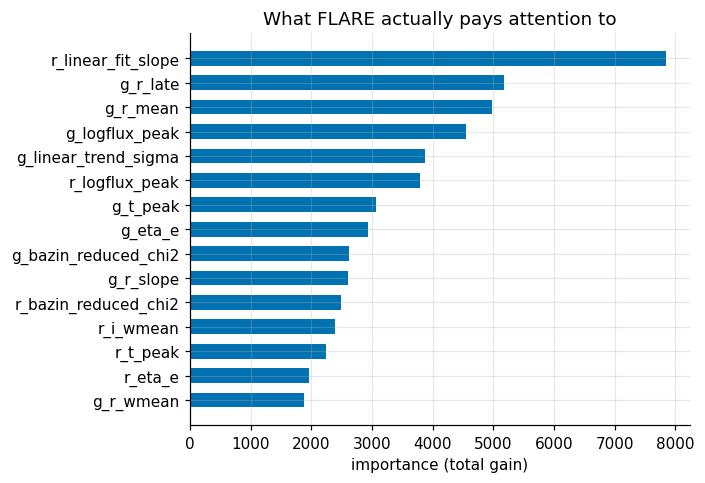

Top features: r_linear_fit_slope, g_r_late, g_r_mean, g_logflux_peak, g_linear_trend_sigma


In [11]:
imp = pd.Series(clf.booster.feature_importance(importance_type="gain"),
                index=clf.feature_names).nlargest(15)[::-1]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(imp.index, imp.values, color="#0072B2", height=0.6)
ax.set_xlabel("importance (total gain)")
ax.set_title("What FLARE actually pays attention to")
plt.tight_layout(); plt.show()
print("Top features:", ", ".join(imp.index[-5:][::-1]))

**Colour (`g_r_*`), smoothness (`eta_e`), and explosion-fit quality (`bazin_*`)
dominate** — the same physics you spotted by eye in Section 1. The machine didn't
learn magic; it learned astronomy. (A full SHAP analysis in the FLARE paper shows,
e.g., that *bluer and more constant colour* pushes objects toward TDE — exactly the
known signature of a black hole shredding a star.)

## 8. What you learned 🎓

1. **Transients** tell their story through light curves — and the classes differ
   in *colour, smoothness, and shape*.
2. **Feature engineering** turns physics into numbers a computer can use.
3. **Gradient-boosted trees** are simple, fast, and excellent on this kind of data
   — you don't always need a giant neural network.
4. **Calibration** is what makes a probability *mean something*.
5. **Conformal prediction** converts predictions into shortlists with a
   mathematical coverage guarantee — even for rare classes.
6. **Interpretability** closes the loop: the model's reasons match the physics.

### 🏆 Final challenge
`models/flare_lgbm_day10.txt` is a version of FLARE trained on only the **first 10
days** of each light curve — the "early warning" regime.
Load it with `FlareClassifier.from_pretrained("../models/flare_lgbm_day10.txt")`,
re-run Section 5 with `horizon_days=10`, and compare the accuracy.
Which classes survive early classification, and which one becomes impossible? Why?

---
*FLARE package: `github.com/<user>/flare` — MIT licensed. Data: ZTF photometric
events. This notebook is part of the FLARE teaching materials.*